In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("creditcard[1].csv") # Changed to creditcard[1].csv

# Display first 5 rows
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


# Credit Card Fraud Detection using Machine Learning

## Objective

The objective of this project is to build a machine learning pipeline that detects fraudulent credit card transactions from a highly imbalanced dataset.

This project focuses on analyzing class imbalance, applying SMOTE for data balancing, training classification models, and evaluating performance using Precision, Recall, F1-Score, and ROC-AUC.

In [10]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Information:")
df.info()

Dataset Shape: (146652, 31)

Columns:
Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146652 entries, 0 to 146651
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    146652 non-null  int64  
 1   V1      146652 non-null  float64
 2   V2      146652 non-null  float64
 3   V3      146652 non-null  float64
 4   V4      146652 non-null  float64
 5   V5      146652 non-null  float64
 6   V6      146652 non-null  float64
 7   V7      146652 non-null  float64
 8   V8      146652 non-null  float64
 9   V9      146652 non-null  float64
 10  V10     146652 non-null  float64
 11  V11     146652 non-null  float64
 12  V12     146652 non-null  fl

## Dataset Inspection

The Credit Card Fraud Detection dataset contains financial transaction records with anonymized features (V1–V28), transaction time, amount, and the target variable **Class**.

### Observation
- The dataset contains both numerical features and one target variable.
- **Class = 0** represents legitimate transactions.
- **Class = 1** represents fraudulent transactions.
- This dataset is highly imbalanced, making fraud detection a challenging classification problem.

In [11]:
# Count of each class
class_count = df["Class"].value_counts()
print(class_count)

# Percentage of fraud transactions
fraud_percent = (class_count[1] / len(df)) * 100

print(f"\nFraud Transactions: {fraud_percent:.3f}%")

Class
0.0    146369
1.0       282
Name: count, dtype: int64

Fraud Transactions: 0.192%


/tmp/ipykernel_3868/375724001.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Class", palette="Blues")


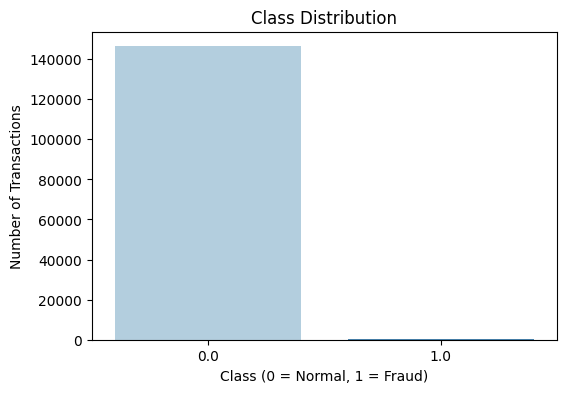

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="Class", palette="Blues")

plt.title("Class Distribution")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

## Class Imbalance Analysis

The visualization clearly shows that fraudulent transactions are extremely rare compared to legitimate transactions.

### Key Finding

- Class **0** dominates the dataset.
- Class **1** represents less than **1%** of all transactions.
- Therefore, **accuracy alone is a misleading evaluation metric**, and metrics such as Precision, Recall, F1-Score, and ROC-AUC are more appropriate for fraud detection.

/tmp/ipykernel_3868/2367890306.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y="Amount", palette="Blues")


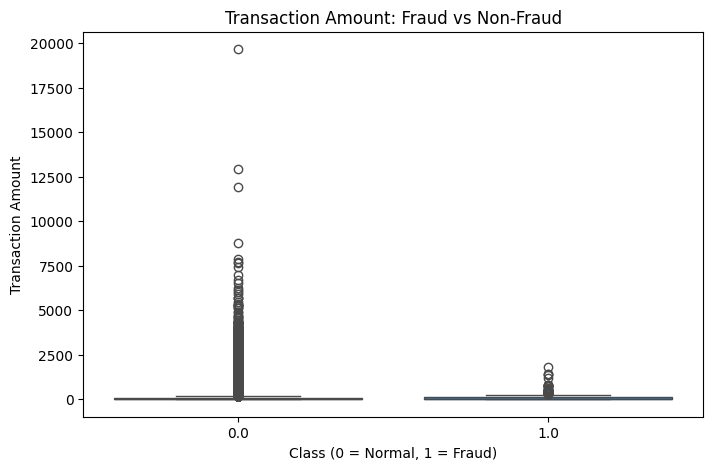

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="Class", y="Amount", palette="Blues")

plt.title("Transaction Amount: Fraud vs Non-Fraud")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.show()

## Exploratory Data Analysis

The box plot compares transaction amounts between legitimate and fraudulent transactions.

### Observation

- Most normal transactions occur within a moderate amount range.
- Fraudulent transactions are fewer but occur across different transaction values.
- Transaction amount alone is not sufficient to identify fraud, so multiple features are required for prediction.

## Why Accuracy is a Misleading Metric

This dataset is highly imbalanced because fraudulent transactions represent less than 1% of all records.

For example, if a model predicts every transaction as **Normal**, it may achieve over **99% accuracy**, yet it completely fails to detect fraud.

Therefore, fraud detection should be evaluated using:

- **Precision:** How many predicted frauds are actually fraud.
- **Recall:** How many actual frauds are correctly detected.
- **F1-Score:** Balance between Precision and Recall.
- **ROC-AUC:** Measures the model's ability to distinguish fraud from normal transactions.

In [15]:
!pip install imbalanced-learn -q

In [17]:
from imblearn.over_sampling import SMOTE

# Drop rows with any NaN values from the DataFrame
df.dropna(inplace=True)

X = df.drop("Class", axis=1)
y = df["Class"]

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Original Shape :", X.shape)
print("After SMOTE    :", X_resampled.shape)

print("\nBalanced Classes:")
print(y_resampled.value_counts())

Original Shape : (146651, 30)
After SMOTE    : (292738, 30)

Balanced Classes:
Class
0.0    146369
1.0    146369
Name: count, dtype: int64


## Class Balancing using SMOTE

SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic samples for the minority class instead of simply duplicating existing fraud records.

### Result

- The dataset becomes balanced.
- Both fraud and non-fraud classes contain equal samples.
- This improves the model's ability to learn fraudulent patterns.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.20,
    random_state=42,
    stratify=y_resampled
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (234190, 30)
Testing Shape : (58548, 30)


## Train-Test Split

The balanced dataset is divided into **80% training** and **20% testing** data using stratified sampling. This ensures both fraud and non-fraud classes are equally represented in both datasets.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

print("Models trained successfully!")

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Models trained successfully!


## Model Training

Two machine learning models were trained for fraud detection:

- **Logistic Regression** (Baseline Model)
- **Random Forest Classifier** (Ensemble Model)

These models are compared to identify the most effective fraud detection algorithm.

In [23]:
lr_pred = lr.predict(X_test)
rf_pred = rf.predict(X_test)

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Precision": [
        precision_score(y_test, lr_pred),
        precision_score(y_test, rf_pred)
    ],
    "Recall": [
        recall_score(y_test, lr_pred),
        recall_score(y_test, rf_pred)
    ],
    "F1 Score": [
        f1_score(y_test, lr_pred),
        f1_score(y_test, rf_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.977215,0.988667,0.965498,0.976945
1,Random Forest,0.999932,0.999898,0.999966,0.999932


/tmp/ipykernel_3868/425125159.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results, x="Model", y="F1 Score", palette="Blues")


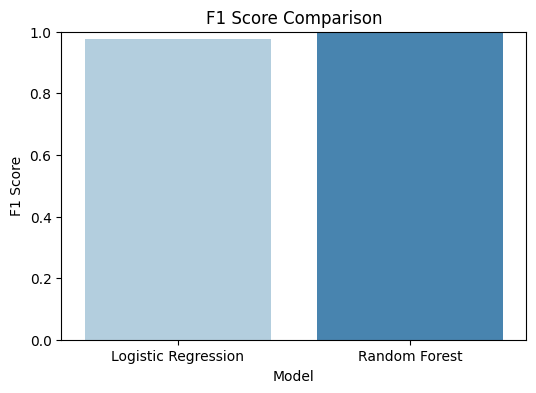

In [25]:
plt.figure(figsize=(6,4))

sns.barplot(data=results, x="Model", y="F1 Score", palette="Blues")

plt.title("F1 Score Comparison")
plt.ylim(0,1)

plt.show()

## Model Evaluation

Instead of relying only on accuracy, Precision, Recall, and F1-Score provide a better evaluation because fraud detection is an imbalanced classification problem.

The model with the highest F1-Score is considered more reliable.

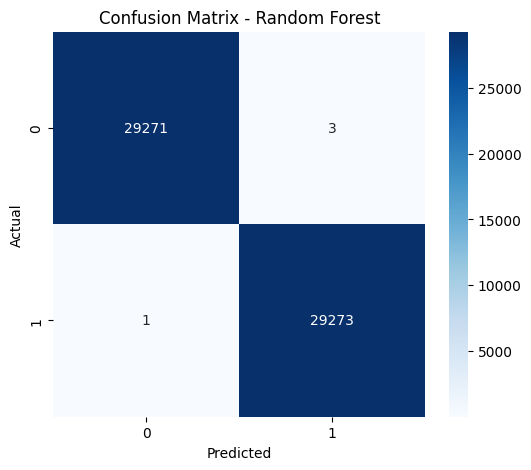

In [26]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

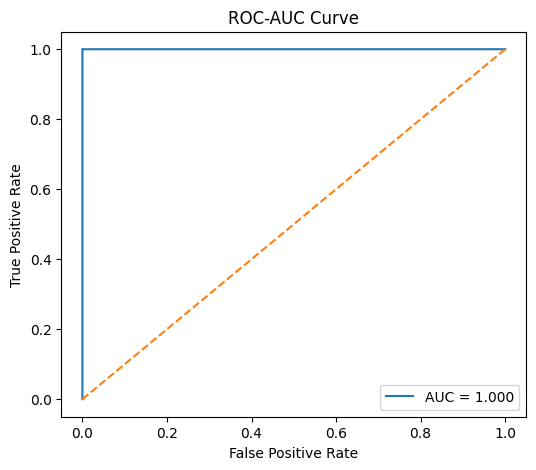

In [27]:
from sklearn.metrics import roc_curve, roc_auc_score

rf_prob = rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, rf_prob)
auc = roc_auc_score(y_test, rf_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve")
plt.legend()

plt.show()

## ROC-AUC Analysis

The ROC-AUC curve measures the model's ability to distinguish fraudulent transactions from legitimate ones.

A higher AUC value indicates better fraud detection performance across different classification thresholds.

/tmp/ipykernel_3868/4275743159.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


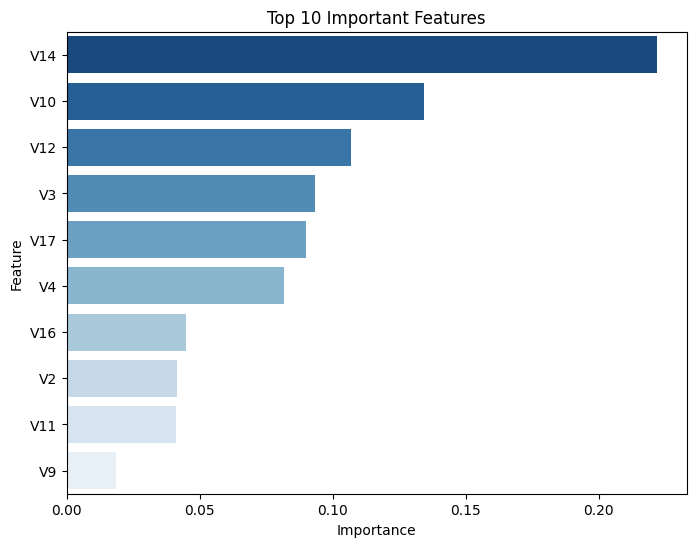

,Feature,Importance
14,V14,0.221864
10,V10,0.134411
12,V12,0.106961
3,V3,0.093310
17,V17,0.090162
4,V4,0.081744
16,V16,0.044980
2,V2,0.041421
11,V11,0.040981
9,V9,0.018552


In [28]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature",
    palette="Blues_r"
)

plt.title("Top 10 Important Features")

plt.show()

importance.head(10)

## Feature Importance

Random Forest identifies the most influential features responsible for detecting fraudulent transactions.

These important variables contribute the most towards distinguishing fraud from legitimate financial activities.

# Conclusion

## Project Summary

This project successfully developed a fraud detection system using machine learning on a highly imbalanced credit card transaction dataset.

## Models Compared

- Logistic Regression
- Random Forest Classifier

## Key Findings

- SMOTE effectively balanced the minority fraud class.
- Random Forest achieved better fraud detection performance than Logistic Regression.
- Precision, Recall, F1-Score, and ROC-AUC are more meaningful than accuracy for fraud detection.

## Scalability Discussion

A production fraud detection system processing millions of transactions per hour can be deployed using distributed data pipelines, real-time feature engineering, and optimized machine learning inference services to ensure low latency and high detection accuracy.

## Technologies Used

- Python
- Pandas
- NumPy
- Seaborn
- Matplotlib
- Scikit-learn
- Imbalanced-learn (SMOTE)

**Outcome:** A complete end-to-end fraud detection machine learning pipeline suitable for real-world financial transaction monitoring.